# Acoustics Homework #4
### Due: Monday April 20, 2026 at Midnight
Problems marked with [*] are potential sources for quiz questions.

Below are necessary imports that will be used to make plots. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.rcParams['figure.figsize'] = (10, 6)

## Problem 1. Rüchardt's Method

A simple harmonic oscillator that combines a gas spring and a (nearly) 
frictionless piston (Airpot®) is shown in Figure 1. The glass cylinder that contains the piston is sealed to a platform that contains a microphone that can measure and record the oscillating pressure within the cylinder if the piston is displaced from its equilibrium position and allowed to execute simple harmonic motion with frequency, $\omega_{0} = 2\pi f_{0} = \sqrt{K_{gas}/m}$. 

The spring constant is defined as:
$$K_{gas}=\frac{\gamma p_{m}}{V}A^{2}=\rho_{m}c^{2}\frac{A^{2}}{V}$$

The text author used a ruler and a marker pen to place marks separated by 1.0 cm along the glass cylinder. The microphone and the PVC protector excluded some of the volume within the cylinder. I assumed the compressible volume was determined by the measured height of the piston plus some “fudge” length, h0, that would take care of any excluded volumes and any offset in my marking of the cylinder’s length.The polytropic coefficient of air, $\gamma_{air}$, is determined by a least-squares fit of the square of the measured periods, $T_{i}^{2}$, plotted against the equilibrium heights of the piston, $h_{i}$:
$$\left[ \frac{p_{m}A}{4\pi^{2}m} \right] T_{i}^{2} = \frac{1}{\gamma_{air}}(h_{i}+h_{0})$$

The polytropic coefficient would therefore be equal to the reciprocal of the slope, γair = (slope)−1, and the “height offset” h0, would be the ratio of the intercept to the slope, h0 = (intercept)/(slope). The data in Table 1 was acquired at an atmospheric pressure of 97.3 kPa. (Is that the mean pressure, pm, within the volume?) Using your favorite method and plotting tools determine γair and the relative uncertainty in slope of the best-fit line. The accepted value for the polytropic coefficient of dry air is γair = 1.403. What is the relative difference 
between your experimental value of γair and the accepted value? If that relative difference is larger than the relative uncertainty in the slope, suggest at least one source of systematic error that could be responsible for that discrepancy

### Problem #1 Solution

This took a bit of research, but the error was due to adiabatic assumption. The derivation assumes the gas compression is perfectly adiaabatic. In the real world though heat exchange occurs between the gas and cylinder walls. This makes the process polytropic ---> $PV^{n} = $ constant where $1 < n < \gamma$. This will lead to a discrepent calculated value of $\gamma$. 

slope: 0.7070803641689767
intercept: -0.002939517039929576
gamma experimental: 1.4142663983821533
h0: -0.0041572601770441696
relative uncertainty in slope: 0.007559700563768501
relative difference: 0.008030219801962411


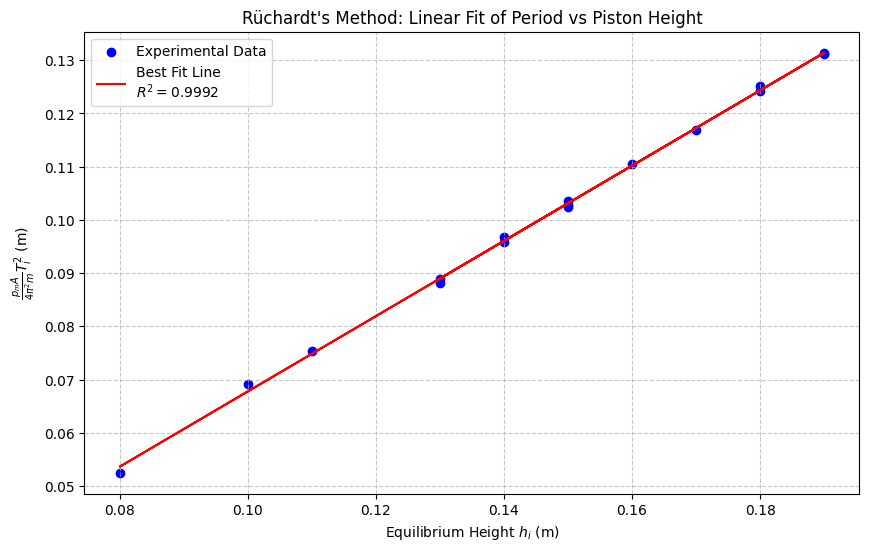

In [ ]:
# Constants
p_m = 97.3e3  # Pa
diameter = 44.33e-3  # m
m = 184.41e-3  # kg
A = np.pi * (diameter / 2)**2
gamma_accepted = 1.403

# Data from Table 1
h_i = np.array([0.15, 0.13, 0.19, 0.18, 0.15, 0.14, 0.13, 0.11, 0.10, 0.08, 0.19, 0.18, 0.17, 0.16, 0.15, 0.14])
T_i_ms = np.array([70.480, 65.400, 79.725, 77.600, 70.567, 68.143, 65.680, 60.467, 57.880, 50.450, 79.800, 77.867, 75.267, 73.200, 70.850, 68.467])

# Transformations
T_i = T_i_ms / 1000.0  # ms to s
T_sq = T_i**2
# Equation: (p_m*A / (4*pi^2*m)) * T^2 = (1/gamma)*(h + h0)
constant_factor = (p_m * A) / (4 * np.pi**2 * m)
Y = constant_factor * T_sq

# Linear Regression
# Y = (1/gamma)*h + (h0/gamma)
slope, intercept, r_value, p_value, std_err = linregress(h_i, Y)

# Calculations
gamma_exp = 1.0 / slope
h0 = intercept / slope
rel_uncert_slope = std_err / slope
rel_diff = abs(gamma_exp - gamma_accepted) / gamma_accepted

# Plotting
plt.scatter(h_i, Y, color='blue', label='Experimental Data')
plt.plot(h_i, slope * h_i + intercept, color='red', label=f'Best Fit Line\n$R^2 = {r_value**2:.4f}$')
plt.xlabel('Equilibrium Height $h_i$ (m)')
plt.ylabel(r'$\frac{p_m A}{4 \pi^2 m} T_i^2$ (m)')
plt.title("Rüchardt's Method: Linear Fit of Period vs Piston Height")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

print(f"slope: {slope}")
print(f"intercept: {intercept}")
print(f"gamma experimental: {gamma_exp}")
print(f"h0: {h0}")
print(f"relative uncertainty in slope: {rel_uncert_slope}")
print(f"relative difference: {rel_diff}")

## Problem 2. Speed of Sound

Show how the speed of sound expression, $$c(m/s) = 331 + 0.6T(^{\circ}C)$$

can be derived by starting with $c = \sqrt{\gamma r T}$ near the freezing point of water ($T = 273K$).

**Hint:** Expand the expression for $c$ in a Taylor Series for $T$ around $T_0 = 273.15 K$.

### Problem 2 Solution: 

To derive the expression $c \approx 331 + 0.6T_c$ , we start with the theoretical speed of sound in an ideal gas:

$$c(T) = \sqrt{\gamma r T}$$

We define our expansion point at the freezing point of water, $T_0 = 273.15 \text{ K}$. We can express any temperature $T$ (in Kelvin) as $T = T_0 + T_c$, where $T_c$ is the temperature in degrees Celsius.

1. Taylor Series ExpansionThe first-order Taylor expansion for a function $f(T)$ centered at $T_0$ is:

$$c(T) \approx c(T_0) + c'(T_0)(T - T_0)$$

First, we find the value of the function at $T_0$:

$$c(T_0) = \sqrt{\gamma r T_0}$$

Next, we find the first derivative of $c(T)$ with respect to $T$:

$$c'(T) = \frac{d}{dT}(\sqrt{\gamma r} T^{1/2}) = \frac{1}{2}\sqrt{\gamma r} T^{-1/2} = \frac{\sqrt{\gamma r}}{2\sqrt{T}}$$

Evaluating the derivative at $T_0$:

$$c'(T_0) = \frac{\sqrt{\gamma r}}{2\sqrt{T_0}}$$

2. Substitution and SimplificationSubstitute these back into the Taylor expansion formula:

$$c(T) \approx \sqrt{\gamma r T_0} + \left( \frac{\sqrt{\gamma r}}{2\sqrt{T_0}} \right)(T - T_0)$$

To simplify, we can multiply the second term by $\frac{\sqrt{T_0}}{\sqrt{T_0}}$:

$$c(T) \approx \sqrt{\gamma r T_0} + \frac{\sqrt{\gamma r T_0}}{2T_0} (T - T_0)$$

Since $(T - T_0) = T_c$, and letting $c_0 = \sqrt{\gamma r T_0}$ represent the speed of sound at $0^{\circ}\text{C}$:

$$c(T) \approx c_0 \left( 1 + \frac{T_c}{2T_0} \right)$$

3. Numerical evaluation using standard values for dry air ($c_0 \approx 331.3 \text{m/s}$ and $T_0 = 273.15 \text{K}$):

$$c(T_c) \approx 331.3 + \left( \frac{331.3}{2 \times 273.15} \right) T_c$$

$$c(T_c) \approx 331.3 + 0.606 T_c$$

After rounding to significant figures as requested by Mr. Dr. Slaton:

$$c(m/s) \approx 331 + 0.6T(^{\circ}C)$$

## Problem 3. Addition of three incoherent sound sources: 

At a particular shop, three machines produce individual sound pressure levels of 90, 93, and 95 $dB_{SPL}$, all referenced to 20 $\mu Pa_{rms}$. Determine the total sound pressure level if all of the machines are running simultaneously. Assume each noise source is statistically independent of all the others so that their powers (not pressures) are combined. Report your result in dB i.e.:20 µParms.

#### Figure 1: 
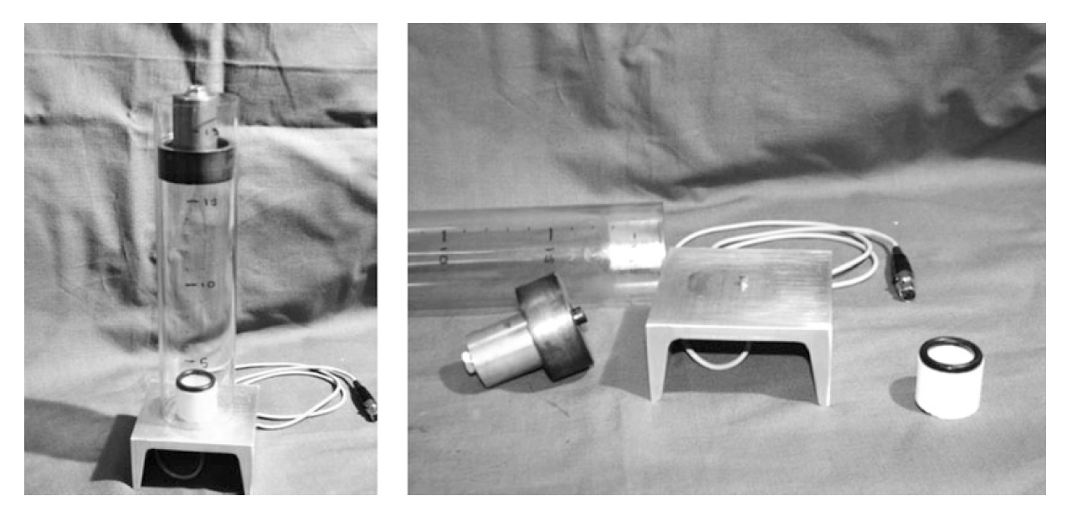

(Left) This simple harmonic oscillator is made from an AirpotTM Precision Air Dashpot, consisting of a glass cylinder and a tight-fitting graphite piston of diameter 44.33 ± 0.03 mm that acts as a gas spring with stiffness, Kgas. The graphite piston and brass cylinder provide a total piston mass, m = 184.41 grams. 
The bottom end of the glass cylinder is sealed to an aluminum platform with vacuum grease. (Right) An Endevco piezorestive pressure sensor is threaded into the platform and is protruding through the platform. The microphone’s electrical output is connected to a digital storage oscilloscope to allow accurate measurement of the natural period of the freely decaying oscillations. The small (white) PVC tube with the rubber O-ring on top is placed over the microphone as protection against any possible collision between the microphone and the graphite piston. 

In [4]:
# Problem 3 Solution: 

L_levels = np.array([90, 93, 95])

L_total = 10 * np.log10(np.sum(10**(L_levels / 10)))

print(f"Total sound pressure level: {L_total:.2f} dB re: 20 µPa")

Total sound pressure level: 97.89 dB re: 20 µPa


## [*] Problem 4. Climate Change: 

Standard dry air historically had a $CO_2$ mole fraction of 314 ppm. As of June 2020, it increased to 415 ppm. How much does this change the speed of sound in dry air? 

1. Approximate the sound speed change by only considering the change in molecular mass, $M_{mix}$, of dry air.

2. Using $\gamma_{air} = 1.4$ and $\gamma_{CO2} = 1.3$, determine if the change in sound speed due to $\gamma_{mix}$ has the same sign as the change due to $M_{mix}$.

3. Use Eqn 10.25 to calculate the change in $\gamma$ and obtain a more accurate result for the total sound speed change.

### Problem 4 Solution: 

1. 
Lets see, CO2 is heavier than air in terms of its molar mass. CO2 has a molar mass of about 44 g/mol. Dry air's molar mass is about 29 g/mol. The average molar mass of dry air, as the CO2 goes up, will increase. An increase of the molar mass will cause a reduction in the speed of sound. 

We treat dry air as a mixture. As the mole fraction of $CO_2$ ($x_{CO2}$) increases, the molar mass $M_{mix}$ increases because $M_{CO2} > M_{air}$.
The relative change in sound speed is:

$$\frac{\Delta c}{c} \approx -\frac{1}{2} \frac{\Delta M}{M}$$

2. 
As CO2 increases, $M_{mix}$ increases, and so c decreases. The Polytropic coefficient effect given $\gamma_{air} = 1.4$ and $\gamma_{CO_{2}} = 1.4$ lowers the overall $\gamma_{air}$. Since $c \propto \sqrt{\gamma}$, a decrease in $\gamma$ also results in a decrease in sound speed. So both effects have the same sign which would be negative. 

3. 
Code below for this part: 

In [8]:
# Constants
M_CO2 = 44.01e-3  # kg/mol
M_air_standard = 28.9645e-3  # kg/mol (at 314 ppm)
gamma_air = 1.4
gamma_CO2 = 1.3
R = 8.314
T = 273.15 + 20 # 20 degrees Celsius

# Mole fractions
x1 = 314e-6
x2 = 415e-6
x_2026 = 429.4e-6 # From footnote

# (a) Molar Mass Calculation
# Determine 'M_other' (mass of air components excluding CO2)
M_other = (M_air_standard - x1 * M_CO2) / (1 - x1)

M_mix1 = x1 * M_CO2 + (1 - x1) * M_other
M_mix2 = x2 * M_CO2 + (1 - x2) * M_other

rel_change_M = (np.sqrt(M_mix1 / M_mix2)) - 1

# (c) Accurate Gamma and Total Change
def get_gamma_mix(x):
    # Based on molar heat capacities mixture rule
    cv_air, cp_air = 1 / (gamma_air - 1), gamma_air / (gamma_air - 1)
    cv_CO2, cp_CO2 = 1 / (gamma_CO2 - 1), gamma_CO2 / (gamma_CO2 - 1)
    cv_mix = (1 - x) * cv_air + x * cv_CO2
    cp_mix = (1 - x) * cp_air + x * cp_CO2
    return cp_mix / cv_mix

gamma_mix1 = get_gamma_mix(x1)
gamma_mix2 = get_gamma_mix(x2)

# Total speed change
c1 = np.sqrt(gamma_mix1 * R * T / M_mix1)
c2 = np.sqrt(gamma_mix2 * R * T / M_mix2)
delta_c = c2 - c1

print(f"--- 314 ppm to 415 ppm ---")
print(f"Rel. change (M only): {rel_change_M*100:.5f}%")
print(f"Total change in sound speed: {delta_c:.5f} m/s")
print(f"Relative total change: {(c2/c1 - 1)*100:.5f}%")

--- 314 ppm to 415 ppm ---
Rel. change (M only): -0.00262%
Total change in sound speed: -0.01066 m/s
Relative total change: -0.00310%


## [*] Problem 5 Schlagwetter-pfeife: 

The presence of methane in mines presents a significant hazard due to the 
possibility of underground explosions. In the late-1880s, one of the world’s most famous industrial chemists, Fritz Haber,3 invented the “methane whistle” to determine the presence of hyrogen or methane in air extracted from underground mines. By 1888, these methane whistles also began to appear in the United Kingdom. Air was pumped from the mine out through one whistle, and fresh air was pumped through the other. Assume the whistles were identical and in good thermal contact, so both surface and subsurface air passing through the whistles were at the same temperature. Determine the concentration (mole fraction) of methane (CH4) in the 
mine air if the air whistle had a frequency of 440 Hz and the pair of whistle produced 10 beats per second at 20◦ C.

#### Table 1: 
Table 1: oscillation periods Ti, in milliseconds, for various equilibrium heights, hi, of the bottom of the graphite piston measured using the apparatus as shown in Figure 1.

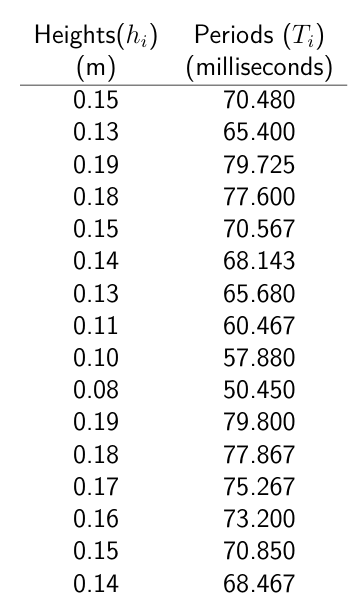

### Problem 5 Solution: 

The frequency of an acoustic resonator is proportional to the speed of sound of the gas filling it. Since methane ($M \approx 16$) is lighter than air ($M \approx 29$), the speed of sound in the mine air will be higher than in pure air, meaning $f_{mine} > f_{air}$.

For a whistle of a fixed length, $f = \frac{v_{sound}}{\lambda}$. Since the wavelength $\lambda$ is determined by the physical dimensions of the whistle, we have $f \propto c$.

When two whistles of slightly different frequencies $f_{air}$ and $f_{mine}$ are blown together, they produce "beats." The beat frequency is $|f_{mine} - f_{air}| = 10 \text{Hz}$.

Methane ($CH_4$) has a molar mass of about 16 g/mol, which is much lighter than air which is about 29 g/mol. A lighter gas increases the speed of sound. Therefore, the mine air whistle will have a higher frequency: $f_{mine} = 440 + 10 = 450$ Hz.

All that is left to do is find the mole fraction that satisfies the below equation: 
$$\frac{f_{mine}}{f_{air}} = \frac{c_{mine}}{c_{air}} = \sqrt{\frac{\gamma_{mine} / M_{mine}}{\gamma_{air} / M_{air}}}$$

I used some code for this one. 

The below results show that a 5 to 6% methane in the air will cause a 10Hz beat frequency. This is important because the lower explosive limit for methan in the air is about 5%. This probably saved many many lives and is part of the reason we have OSHA today. Just kidding, but this was cool to learn about. 

#### Fun Fact: 
I found out today the safety guy at SnapOn was a champion arm wrestler. 

In [9]:
from scipy.optimize import fsolve

# Constants
M_air = 28.97e-3     # kg/mol
M_CH4 = 16.04e-3     # kg/mol
gamma_air = 1.40
gamma_CH4 = 1.31     # Approximate for Methane at 20C

f_air = 440
f_mine = 440 + 10    # Methane is lighter, speed of sound is higher
target_ratio_sq = (f_mine / f_air)**2

def objective(x):
    # Mixture molar mass
    M_mix = x * M_CH4 + (1 - x) * M_air
    
    # Mixture gamma (using heat capacity linear combination)
    cv_air = 1 / (gamma_air - 1)
    cp_air = gamma_air / (gamma_air - 1)
    cv_CH4 = 1 / (gamma_CH4 - 1)
    cp_CH4 = gamma_CH4 / (gamma_CH4 - 1)
    
    cv_mix = x * cv_CH4 + (1 - x) * cv_air
    cp_mix = x * cp_CH4 + (1 - x) * cp_air
    gamma_mix = cp_mix / cv_mix
    
    # The ratio we want to match
    current_ratio_sq = (gamma_mix / M_mix) / (gamma_air / M_air)
    return current_ratio_sq - target_ratio_sq

# Solve for x (mole fraction of methane)
x_methane = fsolve(objective, 0.05)[0]

print(f"Frequency of mine air: {f_mine} Hz")
print(f"Mole fraction of Methane (x): {x_methane:.4f}")
print(f"Percentage of Methane in mine air: {x_methane*100:.2f}%")

Frequency of mine air: 450 Hz
Mole fraction of Methane (x): 0.1189
Percentage of Methane in mine air: 11.89%
